In [1]:
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

#### Get the flood dataset

In [2]:
# MERGED TWICE TO REMOVE DUPLICATES

flood_county = pd.read_csv(
    "../../02_processed_data/fema_flood_county_2000.csv"
).reset_index(drop=True)
flood_county.sort_values(by=["FIPS", "YEAR"]).dropna()
print(flood_county.info())
print(flood_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35450 entries, 0 to 35449
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   FIPS                   35450 non-null  int64  
 1   YEAR                   35450 non-null  int64  
 2   STATE                  35450 non-null  object 
 3   CZ_NAME                35450 non-null  object 
 4   COUNT                  35450 non-null  int64  
 5   TOTAL_DAMAGE_PROPERTY  35450 non-null  float64
 6   TOTAL_DURATION_HOURS   35450 non-null  float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.9+ MB
None
               FIPS          YEAR         COUNT  TOTAL_DAMAGE_PROPERTY  \
count  35450.000000  35450.000000  35450.000000           3.545000e+04   
mean   30434.366008   2010.019069     13.039126           3.367555e+06   
std    14880.622613      6.061159     18.316309           1.256051e+08   
min     1001.000000   2000.000000      1.000000           0.0

#### Get the HPI dataset

In [3]:
hpi_county = pd.read_csv("../../02_processed_data/hpi_county_2000.csv")
hpi_county.sort_values(by=["county_fips5", "yr"]).dropna()
print(hpi_county.info())
print(hpi_county.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103294 entries, 0 to 103293
Data columns (total 6 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   state_name                103294 non-null  object 
 1   county/county_equivalent  103294 non-null  object 
 2   county_fips5              103294 non-null  int64  
 3   yr                        103294 non-null  int64  
 4   hpi_change                99020 non-null   float64
 5   index_nsa                 102279 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 4.7+ MB
None
        county_fips5             yr    hpi_change      index_nsa
count  103294.000000  103294.000000  99020.000000  102279.000000
mean    30137.823339    2004.655120      4.216125     251.727208
std     15165.102342      12.617515      6.537448     194.121414
min      1001.000000    1975.000000    -48.180000      45.290000
25%     18107.000000    1995.000000      0.740000 

#### Checking for missing counties

In [4]:
# hpi_county[hpi_county["cbsa_code"] == "10100"]
flood_county[flood_county["FIPS"] == "46045"]

,FIPS,YEAR,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS


In [5]:
min(hpi_county["county_fips5"]), max(hpi_county["county_fips5"])

(1001, 56045)

In [6]:
mask = ~hpi_county["county_fips5"].isin(flood_county["FIPS"])
hpi_no_flood = hpi_county.loc[mask, "county_fips5"].unique()
hpi_no_flood

array([ 2090,  2110,  2122,  2130,  2150,  2170,  6105,  8003,  8021,
        8065, 26009, 26023, 26095, 26141, 26153, 41031, 53059])

In [7]:
mask = ~flood_county["FIPS"].isin(hpi_county["county_fips5"])
flood_no_hpi = flood_county.loc[mask, "FIPS"].unique()
flood_no_hpi

array([ 1011,  1063,  1105,  2005,  2007,  2014,  2015,  2017,  2018,
        2021,  2022,  2023,  2024,  2025,  2026,  2027,  2028,  2101,
        2111,  2121,  2125,  2131,  2135,  2141,  2145,  2151,  2152,
        2155,  2161,  2171,  2181,  2203,  2207,  2208,  2209,  2210,
        2211,  2213,  2214,  2215,  2216,  2217,  2218,  2219,  2221,
        2222,  2223,  2224,  2225,  2226,  2227,  4011,  5013,  5039,
        5073,  5077,  5095,  5099,  5117,  8009,  8017,  8023,  8061,
       12043, 12067, 13003, 13007, 13037, 13053, 13065, 13101, 13125,
       13167, 13183, 13239, 13243, 13259, 13265, 13271, 13283, 13301,
       13307, 13309, 16025, 16033, 17003, 17013, 17069, 17151, 17153,
       20017, 20019, 20025, 20033, 20039, 20047, 20049, 20063, 20065,
       20071, 20073, 20075, 20083, 20089, 20097, 20101, 20105, 20129,
       20135, 20137, 20141, 20147, 20153, 20157, 20179, 20183, 20185,
       20187, 20199, 20201, 20205, 20207, 21025, 21039, 21063, 21129,
       21131, 21135,

#### Merge flood and HPI datasets

In [9]:
hpi_flood = pd.merge(
    hpi_county[["county_fips5", "yr", "hpi_change"]],
    flood_county,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "YEAR"],
    how="left",
)

# Identify columns that came from flood_county (excluding join keys)
flood_cols = [c for c in flood_county.columns if c not in ["FIPS", "YEAR"]]

# Impute those flood variables as 0
hpi_flood[flood_cols] = hpi_flood[flood_cols].fillna(0)

# Drop join-key duplicates from the merged df
hpi_flood = hpi_flood.drop(columns=["FIPS", "YEAR"])

hpi_flood.head()

,county_fips5,yr,hpi_change,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS
0,1001,1986,NaN,0,0,0.0,0.0,0.0
1,1001,1987,-1.86,0,0,0.0,0.0,0.0
2,1001,1988,2.60,0,0,0.0,0.0,0.0
3,1001,1989,4.30,0,0,0.0,0.0,0.0
4,1001,1990,-0.33,0,0,0.0,0.0,0.0


In [10]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Get heat dataset

In [11]:
heat_county = pd.read_csv(
    "../../02_processed_data/county_heat_index_2000_2020_with_HSI.csv"
).reset_index(drop=True)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Get the fIPS codes for states

In [12]:
us_states_fips = pd.read_csv("../../01_original_data/us_states_fips.csv").reset_index(
    drop=True
)
us_states_fips.head()

,state,fips,longname
0,AL,1,Alabama
1,AK,2,Alaska
2,AZ,4,Arizona
3,AR,5,Arkansas
4,CA,6,California


#### Create FIPS codes in heat dataset

In [13]:
def process_fips(heat_county):
    county_split = str(heat_county).split("-")
    state = str(
        us_states_fips[us_states_fips["state"] == county_split[0]]["fips"].values[0]
    ).zfill(2)
    county = county_split[1]
    return state + county


heat_county["FIPS"] = heat_county["id"].apply(lambda x: process_fips(x))
heat_county["FIPS"] = heat_county["FIPS"].astype(int)
heat_county

,id,name,state,year,value,rank,mean_1901_2000,heat_index,rel_dev,abs_z_year,abs_pct_year,exceed_90,exceed_95,exceed_100,HSI,FIPS
0,AL-001,Autauga County,Alabama,2000,93.8,125.0,90.9,0.400821,0.031903,1.316932,0.906059,3.8,0.0,0.0,0.546615,1001
1,AL-001,Autauga County,Alabama,2001,88.9,18.0,90.9,0.041761,-0.022002,0.622524,0.720271,0.0,0.0,0.0,0.295779,1001
2,AL-001,Autauga County,Alabama,2002,90.8,60.0,90.9,0.182546,-0.001100,0.838350,0.815985,0.8,0.0,0.0,0.378973,1001
3,AL-001,Autauga County,Alabama,2003,88.0,3.0,90.9,-0.009982,-0.031903,0.611812,0.704963,0.0,0.0,0.0,0.277611,1001
4,AL-001,Autauga County,Alabama,2004,88.3,11.0,90.9,0.016426,-0.028603,1.005642,0.811312,0.0,0.0,0.0,0.411246,1001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65242,MD-037,St. Mary&,NaN,2016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65243,MD-037,St. Mary&,NaN,2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65244,MD-037,St. Mary&,NaN,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037
65245,MD-037,St. Mary&,NaN,2019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24037


In [14]:
# CHECKING FOR DUPLICATES
temp = (
    heat_county.value_counts(subset=["FIPS", "year"])
    .reset_index()
    .sort_values(by=["FIPS", "year"])
)
temp[temp["count"] > 1]

,FIPS,year,count


#### Merge heat and HPI/flood datasets

In [15]:
hpi_flood_heat = pd.merge(
    hpi_flood,
    heat_county[["FIPS", "year", "value", "heat_index", "HSI"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Identify columns that came from heat_county, excluding join keys
heat_cols = ["FIPS", "year", "value", "heat_index", "HSI"]

# Impute only heat-related variables as 0
hpi_flood_heat[heat_cols] = hpi_flood_heat[heat_cols].fillna(0)

# Drop join-key duplicates
hpi_flood_heat = hpi_flood_heat.drop(columns=["FIPS", "year"])

hpi_flood_heat.head()
hpi_flood_heat

,county_fips5,yr,hpi_change,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI
0,1001,1986,NaN,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
1,1001,1987,-1.86,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
2,1001,1988,2.60,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
3,1001,1989,4.30,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
4,1001,1990,-0.33,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
103289,56045,2020,4.45,0,0,0.0,0.0,0.0,87.0,0.424372,0.460595
103290,56045,2021,4.97,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
103291,56045,2022,6.15,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000
103292,56045,2023,1.32,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000


In [16]:
# CHECKING FOR DUPLICATES
temp = (
    hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge the drought and wildfire datasets

In [17]:
drought_county = pd.read_csv(
    "../../02_processed_data/NCEI_annual_drought_county_FINAL.csv"
).reset_index(drop=True)
drought_county = drought_county[drought_county["FIPS"] != 0]
drought_county.sort_values(by=["FIPS", "Year"]).dropna()
drought_county = drought_county.drop(["County", "State", "State_abbr"], axis=1)

In [18]:
dupes = drought_county[drought_county.duplicated(subset=["FIPS", "Year"], keep=False)]
dupes = dupes.sort_values(by=["FIPS", "Year"])
drought_county = drought_county.drop_duplicates(subset=["FIPS", "Year"], keep="first")
drought_county.head()

,FIPS,Year,Annual_Mean_Index
0,1001,2000,-2.32
1,1001,2001,1.43
2,1001,2002,-0.76
3,1001,2003,2.39
4,1001,2004,0.00


In [ ]:
drought_hpi_flood_heat = pd.merge(
    hpi_flood_heat,
    drought_county[["FIPS", "Year", "Annual_Mean_Index"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

drought_hpi_flood_heat = drought_hpi_flood_heat.drop(columns=["FIPS", "Year"])

drought_hpi_flood_heat["Annual_Mean_Index"] = drought_hpi_flood_heat[
    "Annual_Mean_Index"
].fillna(0)

drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_change,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index
0,1001,1986,NaN,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1001,1987,-1.86,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1001,1988,2.60,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1001,1989,4.30,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1001,1990,-0.33,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# CHECKING FOR DUPLICATES
temp = (
    drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


In [22]:
wildfire_county = pd.read_csv(
    "../../02_processed_data/wildfire_data_preprocessed.csv"
).reset_index(drop=True)
wildfire_county.sort_values(by=["FIPS", "Year"]).dropna()
wildfire_county = wildfire_county.drop(["State"], axis=1)
wildfire_county.head()

,FIPS,Year,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,1001,2003,43,274.8
1,1001,2004,86,744.5
2,1001,2005,63,234.2
3,1001,2006,62,534.7
4,1001,2007,93,477.3


In [ ]:
wildfire_drought_hpi_flood_heat = pd.merge(
    drought_hpi_flood_heat,
    wildfire_county[["FIPS", "Year", "FIRE_FREQUENCY", "TOTAL_FIRE_SIZE"]],
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "Year"],
    how="left",
)

wildfire_drought_hpi_flood_heat = wildfire_drought_hpi_flood_heat.drop(
    columns=["FIPS", "Year"]
)

wildfire_drought_hpi_flood_heat["FIRE_FREQUENCY"] = wildfire_drought_hpi_flood_heat[
    "FIRE_FREQUENCY"
].fillna(0)
wildfire_drought_hpi_flood_heat["TOTAL_FIRE_SIZE"] = wildfire_drought_hpi_flood_heat[
    "TOTAL_FIRE_SIZE"
].fillna(0)

wildfire_drought_hpi_flood_heat.head()

,county_fips5,yr,hpi_change,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE
0,1001,1986,NaN,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1001,1987,-1.86,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1001,1988,2.60,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1001,1989,4.30,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1001,1990,-0.33,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# CHECKING FOR DUPLICATES
temp = (
    wildfire_drought_hpi_flood_heat.value_counts(subset=["county_fips5", "yr"])
    .reset_index()
    .sort_values(by=["county_fips5", "yr"])
)
temp[temp["count"] > 1]

,county_fips5,yr,count


#### Merge Drought/Wildfire/HPI/Flood/Heat/Hurricane datasets

In [25]:
storm_summary = pd.read_csv(
    "../../02_processed_data/storm_data_aggregated_county.csv", low_memory=False
)
storm_summary["year"] = storm_summary["year"].astype("int")
storm_summary["FIPS"] = storm_summary["FIPS"].astype("int")

huricane_grouped = storm_summary.groupby(["FIPS", "year"], as_index=False).agg(
    deaths_hurricane=("deaths", "sum"),
    injuries_hurricane=("injuries", "sum"),
    damage_hurricane=("damage", "sum"),
)

huricane_grouped.sort_values(by=["FIPS", "year"])

,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1003,2002,0.0,0.0,75000
1,1003,2004,0.0,0.0,0
2,1003,2005,0.0,0.0,0
3,1003,2020,2.0,0.0,236080000
4,1013,2004,0.0,0.0,0
...,...,...,...,...,...
947,51730,2003,1.0,0.0,9700000
948,51740,2003,0.0,0.0,10000000
949,51800,2003,0.0,0.0,33000000
950,51810,2003,0.0,0.0,39400000


In [26]:
wildfire_drought_hpi_flood_heat_huricane = pd.merge(
    wildfire_drought_hpi_flood_heat,
    huricane_grouped,
    left_on=["county_fips5", "yr"],
    right_on=["FIPS", "year"],
    how="left",
)

# Columns coming from huricane_grouped, excluding join keys
hurricane_cols = [c for c in huricane_grouped.columns if c not in ["FIPS", "year"]]

# Impute only hurricane variables as 0
wildfire_drought_hpi_flood_heat_huricane[hurricane_cols] = (
    wildfire_drought_hpi_flood_heat_huricane[hurricane_cols].fillna(0)
)


wildfire_drought_hpi_flood_heat_huricane

,county_fips5,yr,hpi_change,STATE,CZ_NAME,COUNT,TOTAL_DAMAGE_PROPERTY,TOTAL_DURATION_HOURS,value,heat_index,HSI,Annual_Mean_Index,FIRE_FREQUENCY,TOTAL_FIRE_SIZE,FIPS,year,deaths_hurricane,injuries_hurricane,damage_hurricane
0,1001,1986,NaN,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
1,1001,1987,-1.86,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
2,1001,1988,2.60,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
3,1001,1989,4.30,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
4,1001,1990,-0.33,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103289,56045,2020,4.45,0,0,0.0,0.0,0.0,87.0,0.424372,0.460595,0.24,50.0,700.61,NaN,NaN,0.0,0.0,0.0
103290,56045,2021,4.97,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
103291,56045,2022,6.15,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0
103292,56045,2023,1.32,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.00,0.0,0.00,NaN,NaN,0.0,0.0,0.0


In [ ]:
df = wildfire_drought_hpi_flood_heat_huricane

# columns to drop
cols_to_drop = [
    "YEAR",
    "year_y",
    "State_fire",
    "State_ncei",
    "State_abbr",
    "Year",
    "county_fips5",
    "year_x",
    "FIPS",
    "year",
    "value",
    "heat_index",
]

# drop them from df (ignore any that might be missing)
df = df.drop(columns=cols_to_drop, errors="ignore")

# quick check
print(df.columns)
print(df.info())
print(df.describe())

Index(['yr', 'hpi_change', 'STATE', 'CZ_NAME', 'COUNT',
       'TOTAL_DAMAGE_PROPERTY', 'TOTAL_DURATION_HOURS', 'HSI',
       'Annual_Mean_Index', 'FIRE_FREQUENCY', 'TOTAL_FIRE_SIZE',
       'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103294 entries, 0 to 103293
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   yr                     103294 non-null  int64  
 1   hpi_change             99020 non-null   float64
 2   STATE                  103294 non-null  object 
 3   CZ_NAME                103294 non-null  object 
 4   COUNT                  103294 non-null  float64
 5   TOTAL_DAMAGE_PROPERTY  103294 non-null  float64
 6   TOTAL_DURATION_HOURS   103294 non-null  float64
 7   HSI                    103294 non-null  float64
 8   Annual_Mean_Index      103294 non-null  float64
 9   FIRE_FREQUENCY         10

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

In [29]:
df = df.rename(
    columns={
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "HSI": "HEAT_STRESS_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
    }
)
df.columns

Index(['yr', 'hpi_change', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_STRESS_INDEX',
       'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY', 'FIRE_SIZE',
       'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane'],
      dtype='object')

## OLS Regression


Numeric predictors used:
['yr', 'FLOOD_FREQUENCY', 'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_STRESS_INDEX', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY', 'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane']

=== OLS Summary ===
                            OLS Regression Results                            
Dep. Variable:             hpi_change   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     612.1
Date:                Fri, 16 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:46:22   Log-Likelihood:            -3.2316e+05
No. Observations:               99020   AIC:                         6.463e+05
Df Residuals:                   99008   BIC:                         6.465e+05
Df Model:                          11                                         
Covariance Type:        

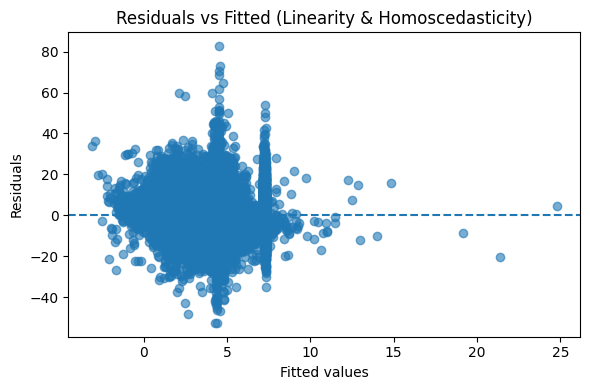

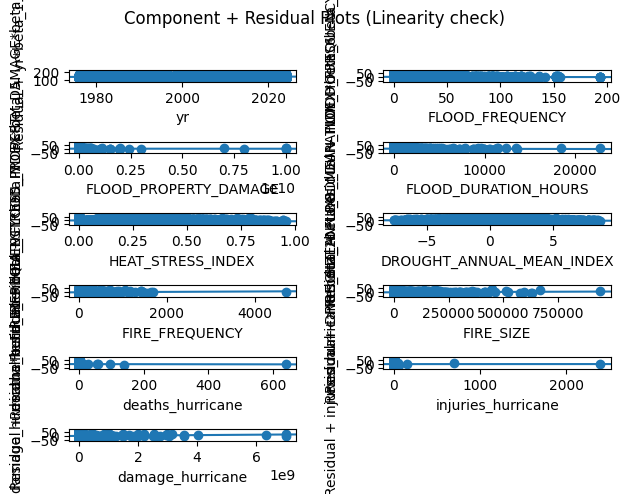


Durbin–Watson statistic: 1.496


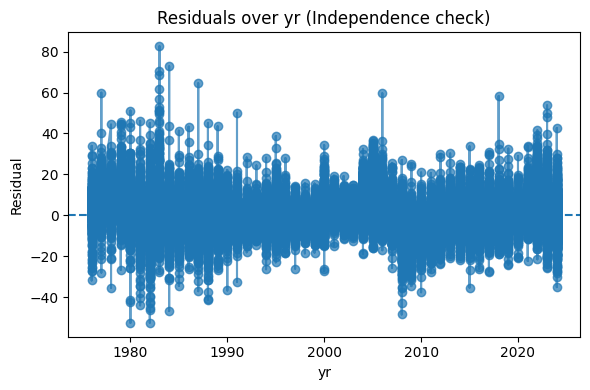

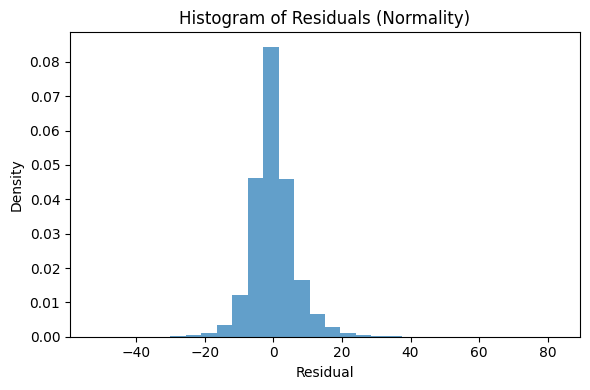

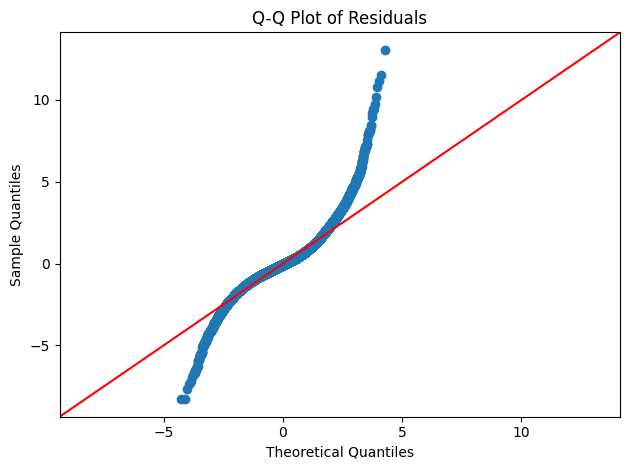


Shapiro–Wilk: stat=0.943, p=4.26e-97
Jarque–Bera: stat=126404.084, p=0, skew=0.660, kurtosis=8.375


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 99020.
  res = hypotest_fun_out(*samples, **kwds)


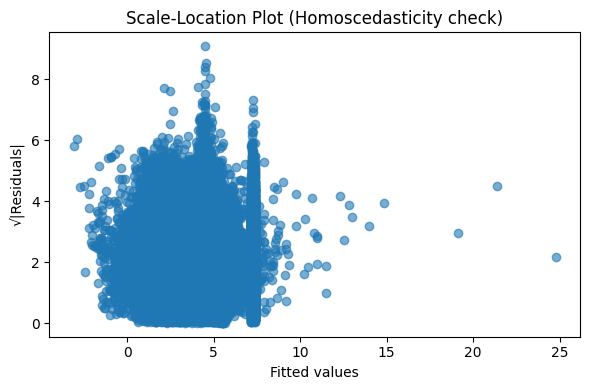

X_exog shape for BP: (99020, 12)

Breusch–Pagan test: LM stat=1192.703, p=6.05e-249, F=109.736, F p=1.74e-250


In [ ]:
# -------------------------------------------
# 1. Build X and y
# -------------------------------------------
target = "hpi_change"

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
exclude_cols = [target]  # response only; FIPS is already dropped

predictors = [c for c in numeric_cols if c not in exclude_cols]
print("\nNumeric predictors used:")
print(predictors)

X = df[predictors].copy()
y = df[target]

# Drop any constant or duplicate columns just to be safe
constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    X = X.drop(columns=constant_cols)

dup_mask = X.T.duplicated()
if dup_mask.any():
    print("Dropping duplicate columns:", list(X.columns[dup_mask]))
    X = X.loc[:, ~dup_mask]

# Add intercept
X = sm.add_constant(X)

# -------------------------------------------
# 2. Fit OLS
# -------------------------------------------
model = sm.OLS(y, X, missing="drop").fit()
print("\n=== OLS Summary ===")
print(model.summary())

resid = model.resid
fitted = model.fittedvalues

# -------------------------------------------
# 3. L – Linearity
# -------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(fitted, resid, alpha=0.6)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Linearity & Homoscedasticity)")
plt.tight_layout()
plt.show()

fig = sm.graphics.plot_ccpr_grid(model)
fig.suptitle("Component + Residual Plots (Linearity check)", y=1.02)
plt.tight_layout()
plt.show()

# -------------------------------------------
# 4. I – Independence
# -------------------------------------------
dw = durbin_watson(resid)
print(f"\nDurbin–Watson statistic: {dw:.3f}")

# If 'yr' is still in df, use it as time variable
if "yr" in df.columns:
    temp = pd.DataFrame({"yr": df["yr"], "resid": resid}).dropna()
    temp = temp.sort_values(by="yr")
    plt.figure(figsize=(6, 4))
    plt.plot(temp["yr"], temp["resid"], marker="o", linestyle="-", alpha=0.7)
    plt.axhline(0, linestyle="--")
    plt.xlabel("yr")
    plt.ylabel("Residual")
    plt.title("Residuals over yr (Independence check)")
    plt.tight_layout()
    plt.show()

# -------------------------------------------
# 5. N – Normality
# -------------------------------------------
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, density=True, alpha=0.7)
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Histogram of Residuals (Normality)")
plt.tight_layout()
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

shapiro_stat, shapiro_p = stats.shapiro(resid)
print(f"\nShapiro–Wilk: stat={shapiro_stat:.3f}, p={shapiro_p:.3g}")

jb_stat, jb_p, skew, kurt = sm.stats.jarque_bera(resid)
print(
    f"Jarque–Bera: stat={jb_stat:.3f}, p={jb_p:.3g}, skew={skew:.3f}, kurtosis={kurt:.3f}"
)

from statsmodels.tools.tools import fullrank

# ---------------------------------------------------
# 7. E – Equal variance (Scale-location + Breusch–Pagan)
# ---------------------------------------------------
plt.figure(figsize=(6, 4))
plt.scatter(fitted, np.sqrt(np.abs(resid)), alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("√|Residuals|")
plt.title("Scale-Location Plot (Homoscedasticity check)")
plt.tight_layout()
plt.show()

X_exog = model.model.exog
print("X_exog shape for BP:", X_exog.shape)

# Only run BP if we have constant + at least 1 predictor
if X_exog.shape[1] < 2:
    print(
        "\nNot enough predictors to run Breusch–Pagan test (need constant + at least 1 covariate)."
    )
else:
    bp_stat, bp_p, bp_f, bp_f_p = het_breuschpagan(resid, X_exog)
    print(
        f"\nBreusch–Pagan test: LM stat={bp_stat:.3f}, p={bp_p:.3g}, "
        f"F={bp_f:.3f}, F p={bp_f_p:.3g}"
    )

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[
    [
        "FLOOD_FREQUENCY",
        "FLOOD_PROPERTY_DAMAGE",
        "FLOOD_DURATION_HOURS",
        "HEAT_STRESS_INDEX",
        "DROUGHT_ANNUAL_MEAN_INDEX",
        "FIRE_FREQUENCY",
        "FIRE_SIZE",
        "deaths_hurricane",
        "injuries_hurricane",
        "damage_hurricane",
    ]
]

# Standardize or just keep as-is
vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_df)

                    variable       VIF
0            FLOOD_FREQUENCY  1.300912
1      FLOOD_PROPERTY_DAMAGE  1.001009
2       FLOOD_DURATION_HOURS  1.075153
3          HEAT_STRESS_INDEX  1.406949
4  DROUGHT_ANNUAL_MEAN_INDEX  1.134947
5             FIRE_FREQUENCY  1.248682
6                  FIRE_SIZE  1.040700
7           deaths_hurricane  1.128565
8         injuries_hurricane  1.028924
9           damage_hurricane  1.159824


## Ridge Regression

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

X_ridge = df[predictors].copy()
y_ridge = df[target].copy()

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv = make_pipeline(
    StandardScaler(), RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
)

ridge_cv.fit(X_ridge, y_ridge)

ridge_step = ridge_cv.named_steps["ridgecv"]
print("Chosen alpha:", ridge_step.alpha_)

y_pred_ridge = ridge_cv.predict(X_ridge)
print("Ridge MSE:", mean_squared_error(y_ridge, y_pred_ridge))
print("Ridge R^2:", r2_score(y_ridge, y_pred_ridge))

# Coefficients on standardized scale:
for name, coef in zip(predictors, ridge_step.coef_):
    print(f"{name:30s} {coef: .4f}")

ValueError: 
All the 25 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_ridge.py", line 1239, in fit
    X, y = validate_data(
           ^^^^^^^^^^^^^^
  File "/Library/Fram

## ar(1)

     yr   hpi_yoy
0  2000  1.226954
1  2001  4.070521
2  2002  2.850440
3  2003  2.620052
4  2004  4.455241
yr
2000    4.509167
2001    5.881094
2002    4.767851
2003    5.167268
2004    7.155412
Name: hpi_yoy, dtype: float64


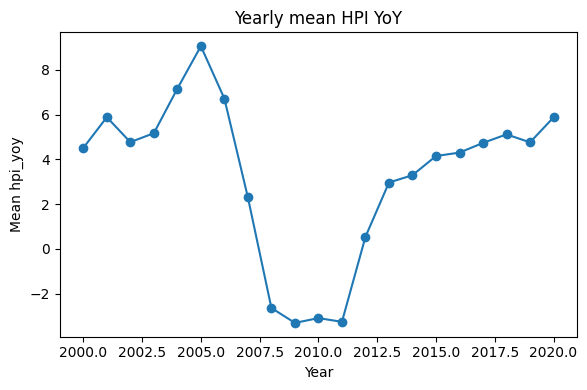

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# starting from your cleaned df
# it must have columns: 'yr' and 'hpi_yoy'
print(df[["yr", "hpi_yoy"]].head())

# 1) aggregate to yearly mean HPI YoY across counties
hpi_yearly = df.groupby("yr", as_index=True)["hpi_yoy"].mean().sort_index()

print(hpi_yearly.head())

# quick plot
plt.figure(figsize=(6, 4))
hpi_yearly.plot(marker="o")
plt.title("Yearly mean HPI YoY")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# AR(1) ≡ ARIMA(p=1, d=0, q=0)
ar1_model = ARIMA(hpi_yearly, order=(1, 0, 0)).fit()

print(ar1_model.summary())

                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -44.113
Date:                Fri, 16 Jan 2026   AIC                             94.225
Time:                        17:56:29   BIC                             97.359
Sample:                             0   HQIC                            94.905
                                 - 21                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.8489      2.998      1.284      0.199      -2.028       9.725
ar.L1          0.8153      0.118      6.887      0.000       0.583       1.047
sigma2         3.7109      1.237      2.999      0.0

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


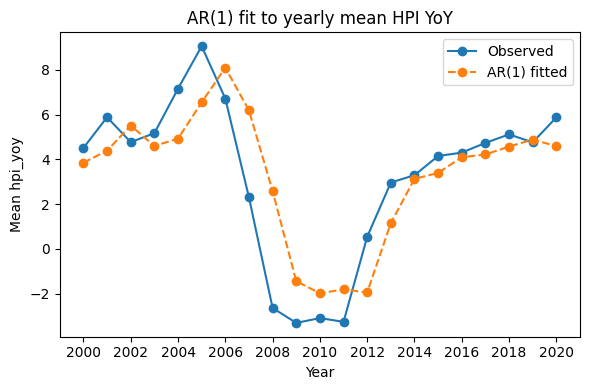

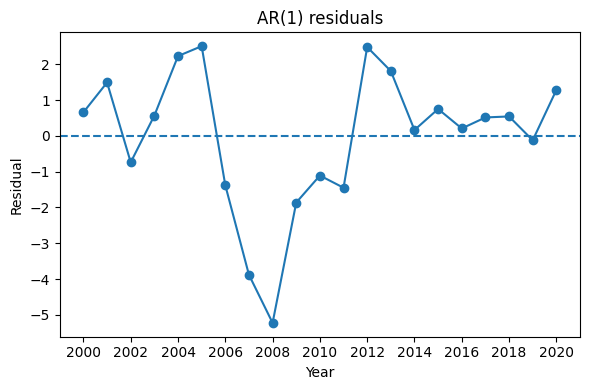

In [ ]:
# Fitted values (in-sample)
fitted_ar1 = ar1_model.fittedvalues

plt.figure(figsize=(6, 4))
plt.plot(hpi_yearly.index, hpi_yearly, marker="o", label="Observed")
plt.plot(hpi_yearly.index, fitted_ar1, marker="o", linestyle="--", label="AR(1) fitted")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.title("AR(1) fit to yearly mean HPI YoY")
plt.legend()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

# Residuals
resid_ar1 = ar1_model.resid

plt.figure(figsize=(6, 4))
plt.plot(hpi_yearly.index, resid_ar1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.title("AR(1) residuals")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

#### We aggregated county-level HPI growth to yearly means and fit an AR(1) model, $Y_t = c + \phi_1 Y_{t-1} + \varepsilon_t$. The estimated AR coefficient $\hat{\phi}_1 = 0.82$ ($p < 0.001$) indicates strong persistence in annual HPI growth: high-growth years tend to be followed by high growth in the next year. The model captures the broad rise, crash around 2008--2011, and subsequent recovery, but residuals remain large during the crash period, reflecting shocks that are not well captured by a simple AR(1) structure.


## add other predictors on AR(1) model with PCA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler

# Define hazard predictors (excluding year and HPI target)
exog_vars = [
    "FLOOD_FREQUENCY",
    "FLOOD_PROPERTY_DAMAGE",
    "FLOOD_DURATION_HOURS",
    "HEAT_STRESS_INDEX",
    "DROUGHT_ANNUAL_MEAN_INDEX",
    "FIRE_FREQUENCY",
    "FIRE_SIZE",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
]

# Aggregate to yearly means
yearly = df.groupby("yr")[["hpi_yoy"] + exog_vars].mean().sort_index()

# Define target and predictors for ARIMA
y_ts = yearly["hpi_yoy"]

scaler = StandardScaler()
X_scaled = StandardScaler().fit_transform(yearly[exog_vars])
X_ts = pd.DataFrame(X_scaled, columns=exog_vars, index=yearly.index)

In [ ]:
# AR(1) with exogenous regressors
ar1_x_model = ARIMA(endog=y_ts, exog=X_ts, order=(1, 0, 0)).fit()
print(ar1_x_model.summary())

                               SARIMAX Results                                
Dep. Variable:                hpi_yoy   No. Observations:                   21
Model:                 ARIMA(1, 0, 0)   Log Likelihood                 -38.775
Date:                Fri, 16 Jan 2026   AIC                            103.549
Time:                        17:56:29   BIC                            117.128
Sample:                             0   HQIC                           106.496
                                 - 21                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         3.5057      3.646      0.962      0.336      -3.640      10.651
FLOOD_FREQUENCY              -0.9990      0.996     -1.003      0.316      -2.951     

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


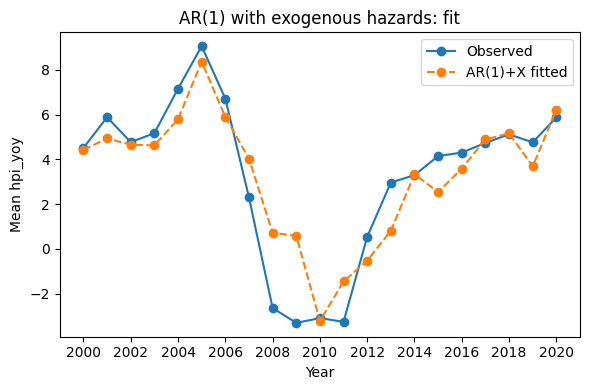

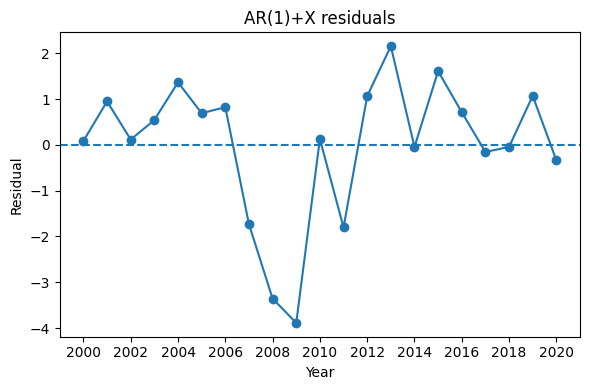

In [ ]:
# In-sample fitted values
fitted_ar1x = ar1_x_model.fittedvalues

plt.figure(figsize=(6, 4))
plt.plot(y_ts.index, y_ts, marker="o", label="Observed")
plt.plot(y_ts.index, fitted_ar1x, marker="o", linestyle="--", label="AR(1)+X fitted")
plt.xlabel("Year")
plt.ylabel("Mean hpi_yoy")
plt.title("AR(1) with exogenous hazards: fit")
plt.legend()
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

# Residuals
resid_ar1x = ar1_x_model.resid

plt.figure(figsize=(6, 4))
plt.plot(y_ts.index, resid_ar1x, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Residual")
plt.title("AR(1)+X residuals")
plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
plt.tight_layout()
plt.show()

#### We extended the AR(1) model for yearly mean HPI growth to include exogenous measures of flood, heat, drought, fire, and hurricane hazards (ARIMAX(1,0,0)). While the exogenous terms largely removed the residual autocorrelation (Ljung–Box p = 0.83 and an insignificant AR(1) coefficient), the model is heavily over-parameterized for a 21-year series, leading to an ill-conditioned covariance matrix and unstable, difficult-to-interpret coefficient estimates. In practice, a more parsimonious specification with a small number of hazard indices (or regularization) would be preferable.

## Random Effect County with PCA (panel model)

In [ ]:
df_county = wildfire_drought_hpi_flood_heat_huricane
df_county = df_county.rename(
    columns={
        "COUNT": "FLOOD_FREQUENCY",
        "TOTAL_DAMAGE_PROPERTY": "FLOOD_PROPERTY_DAMAGE",
        "TOTAL_DURATION_HOURS": "FLOOD_DURATION_HOURS",
        "HSI": "HEAT_STRESS_INDEX",
        "Annual_Mean_Index": "DROUGHT_ANNUAL_MEAN_INDEX",
        "TOTAL_FIRE_SIZE": "FIRE_SIZE",
    }
)
df_county.columns

Index(['county_fips5', 'yr', 'hpi_yoy', 'STATE', 'CZ_NAME', 'FLOOD_FREQUENCY',
       'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'value', 'heat_index',
       'HEAT_STRESS_INDEX', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY',
       'FIRE_SIZE', 'FIPS', 'year', 'deaths_hurricane', 'injuries_hurricane',
       'damage_hurricane'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
import pandas as pd

df_county = df_county.sort_values(["county_fips5", "yr"])
df_county["hpi_yoy_lag1"] = df_county.groupby("county_fips5")["hpi_yoy"].shift(1)
df_lagged = df_county.dropna(subset=["hpi_yoy_lag1"]).reset_index(drop=True)

scaler = StandardScaler()
X_scaled_mixed = scaler.fit_transform(df_lagged[exog_vars])
df_scaled = pd.DataFrame(X_scaled_mixed, columns=exog_vars, index=df_lagged.index)

df_lagged = pd.concat([df_lagged, df_scaled], axis=1)

formula_raw = "hpi_yoy ~ hpi_yoy_lag1 + " + " + ".join(exog_vars)

model_mixed = smf.mixedlm(formula_raw, data=df_lagged, groups=df_lagged["county_fips5"])
result_mixed = model_mixed.fit()

print(result_mixed.summary())

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          hpi_yoy    
No. Observations:            20919            Method:                      REML       
No. Groups:                  1046             Scale:                       10.5728    
Min. group size:             19               Log-Likelihood:              -54299.6224
Max. group size:             20               Converged:                   No         
Mean group size:             20.0                                                     
--------------------------------------------------------------------------------------
                             Coef.    Std.Err.     z    P>|z|    [0.025       0.975]  
--------------------------------------------------------------------------------------
Intercept                     0.232                                                   
hpi_yoy_lag1                  0.777       0.004 180.159 0.000       

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 60.441331
  warnings.warn(msg, ConvergenceWarning)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, Convergenc

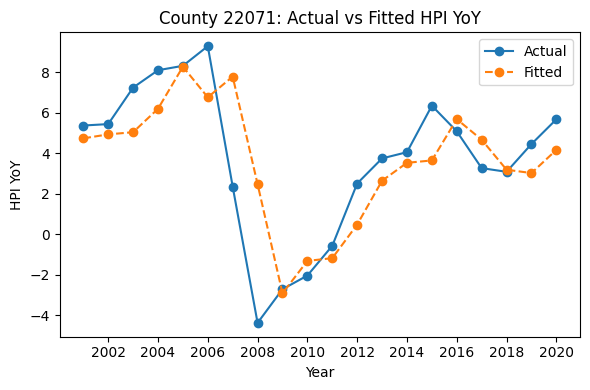

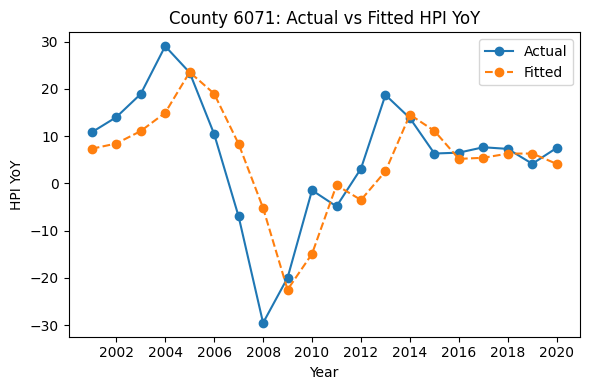

In [ ]:
import numpy as np
import matplotlib.ticker as ticker

df_lagged["fitted"] = result_mixed.fittedvalues

# 22071--Louisana (New Orlands--Hurricane),
target_fips = [22071, 6071]

for fips in target_fips:
    subdf = df_lagged[df_lagged["county_fips5"] == fips]

    plt.figure(figsize=(6, 4))
    plt.plot(subdf["yr"], subdf["hpi_yoy"], marker="o", label="Actual")
    plt.plot(subdf["yr"], subdf["fitted"], marker="o", linestyle="--", label="Fitted")
    plt.title(f"County {fips}: Actual vs Fitted HPI YoY")
    plt.xlabel("Year")
    plt.ylabel("HPI YoY")
    plt.legend()
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(2))
    plt.tight_layout()
    plt.show()

In [ ]:
import bambi as bmb
import pandas as pd
import arviz as az
from sklearn.preprocessing import StandardScaler

df_lagged_bayes = df_lagged.copy()
df_lagged_bayes = df_lagged_bayes.loc[
    :, ~df_lagged_bayes.columns.duplicated(keep="last")
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_lagged_bayes[exog_vars])
df_scaled = pd.DataFrame(X_scaled, columns=exog_vars, index=df_lagged_bayes.index)

for col in exog_vars:
    df_lagged_bayes[col] = df_scaled[col]

formula = "hpi_yoy ~ hpi_yoy_lag1 + " + " + ".join(exog_vars) + " + (1|county_fips5)"

model = bmb.Model(formula=formula, data=df_lagged_bayes)
results = model.fit(draws=1000, tune=1000, cores=1)

az.summary(results, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, Intercept, hpi_yoy_lag1, FLOOD_FREQUENCY, FLOOD_PROPERTY_DAMAGE, FLOOD_DURATION_HOURS, HEAT_STRESS_INDEX, DROUGHT_ANNUAL_MEAN_INDEX, FIRE_FREQUENCY, FIRE_SIZE, deaths_hurricane, injuries_hurricane, damage_hurricane, 1|county_fips5_sigma, 1|county_fips5_offset]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 61 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.25,0.02,3.22,3.28,0.0,0.0,4765.94,1435.95,1.0
Intercept,0.77,0.03,0.72,0.82,0.0,0.0,4141.62,1429.62,1.0
hpi_yoy_lag1,0.78,0.00,0.77,0.78,0.0,0.0,4749.62,1374.62,1.0
FLOOD_FREQUENCY,-0.03,0.02,-0.07,0.02,0.0,0.0,3412.20,1423.67,1.0
FLOOD_PROPERTY_DAMAGE,-0.00,0.02,-0.05,0.04,0.0,0.0,3370.94,1162.30,1.0
...,...,...,...,...,...,...,...,...,...
1|county_fips5[55131],-0.00,0.02,-0.05,0.05,0.0,0.0,2308.39,1553.68,1.0
1|county_fips5[55133],-0.00,0.03,-0.05,0.05,0.0,0.0,2585.97,1366.03,1.0
1|county_fips5[55139],0.00,0.02,-0.04,0.05,0.0,0.0,2910.20,1792.72,1.0
1|county_fips5[56021],-0.00,0.03,-0.05,0.05,0.0,0.0,3071.02,1704.10,1.0


In [ ]:
formula_fe = "hpi_yoy ~ hpi_yoy_lag1 + " + " + ".join(exog_vars)
model_simple = bmb.Model(formula=formula_fe, data=df_lagged_bayes)
results_simple = model_simple.fit(draws=1000, tune=1000, chains=2, cores=1)
az.summary(results_simple, round_to=2)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [sigma, Intercept, hpi_yoy_lag1, FLOOD_FREQUENCY, FLOOD_PROPERTY_DAMAGE, FLOOD_DURATION_HOURS, HEAT_STRESS_INDEX, DROUGHT_ANNUAL_MEAN_INDEX, FIRE_FREQUENCY, FIRE_SIZE, deaths_hurricane, injuries_hurricane, damage_hurricane]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 15 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,3.25,0.02,3.22,3.28,0.0,0.0,3249.38,1533.57,1.0
Intercept,0.77,0.03,0.73,0.82,0.0,0.0,3672.65,1817.34,1.0
hpi_yoy_lag1,0.78,0.00,0.77,0.79,0.0,0.0,3412.01,1524.38,1.0
FLOOD_FREQUENCY,-0.03,0.02,-0.07,0.02,0.0,0.0,3396.72,1343.44,1.0
FLOOD_PROPERTY_DAMAGE,-0.00,0.02,-0.05,0.04,0.0,0.0,3153.48,1264.08,1.0
FLOOD_DURATION_HOURS,-0.07,0.02,-0.11,-0.02,0.0,0.0,3487.24,1442.80,1.0
HEAT_STRESS_INDEX,-0.13,0.03,-0.18,-0.08,0.0,0.0,3080.68,1435.80,1.0
DROUGHT_ANNUAL_MEAN_INDEX,0.19,0.03,0.14,0.24,0.0,0.0,2817.87,1533.36,1.0
FIRE_FREQUENCY,0.02,0.02,-0.02,0.07,0.0,0.0,3572.43,1757.12,1.0
FIRE_SIZE,0.06,0.02,0.01,0.10,0.0,0.0,3429.73,1749.93,1.0


In [ ]:
ppc_preds = model_simple.predict(results_simple, kind="pps", inplace=False)

y_pred = ppc_preds.posterior_predictive["hpi_yoy"].mean(dim=["chain", "draw"]).values
y_true = df_lagged_bayes["hpi_yoy"].values


import numpy as np

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

bayes_r2 = 1 - (ss_res / ss_tot)
print(f"Bayesian R²: {bayes_r2:.4f}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


Bayesian R²: 0.6099


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='hpi_yoy'>

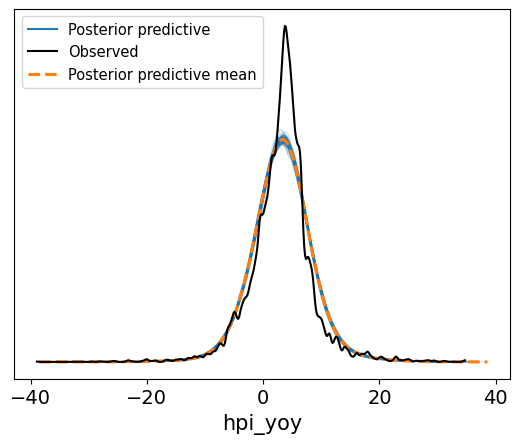

In [ ]:
ppc_preds = model_simple.predict(results_simple, kind="pps", inplace=False)

idata_ppc = results_simple.copy()
idata_ppc.add_groups(posterior_predictive=ppc_preds.posterior_predictive)

az.plot_ppc(idata_ppc, var_names=["hpi_yoy"], group="posterior", num_pp_samples=100)

In [ ]:
model_baseline = bmb.Model("hpi_yoy ~ hpi_yoy_lag1", data=df_lagged_bayes)
results_base = model_baseline.fit(draws=1000, tune=1000)
ppc_base = model_baseline.predict(results_base, kind="pps", inplace=False)

y_pred_base = (
    ppc_base.posterior_predictive["hpi_yoy"].mean(dim=["chain", "draw"]).values
)
y_true_base = df_lagged_bayes["hpi_yoy"].values

r2_base = 1 - (
    np.sum((y_true_base - y_pred_base) ** 2)
    / np.sum((y_true_base - np.mean(y_true_base)) ** 2)
)
print(f"Baseline R² (only lag): {r2_base:.4f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, hpi_yoy_lag1]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 2 seconds.
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


Baseline R² (only lag): 0.6068


In [ ]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# ---------- 1. Choose features & target ----------
target = "hpi_yoy"

# use all numeric columns except target as features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in numeric_cols if c != target]

print("Features:", feature_cols)
print("Target:", target)

X = df[feature_cols].values.astype(np.float32)
y = df[target].values.astype(np.float32).reshape(-1, 1)

# ---------- 2. Train/val/test split ----------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

# ---------- 3. Scale features (fit on train only) ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# ---------- 4. Torch Dataset wrappers ----------
class HPIDataset(Dataset):
    def __init__(self, X, y):
        # X shape: (N, num_features)
        # CNN1d expects (N, C, L) -> we'll use C=1 channel
        self.X = torch.from_numpy(X).float().unsqueeze(1)  # (N, 1, L)
        self.y = torch.from_numpy(y).float()  # (N, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = HPIDataset(X_train_scaled, y_train)
val_ds = HPIDataset(X_val_scaled, y_val)
test_ds = HPIDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)


class HPI_CNN(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        # seq_len = number of features
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),  # halves sequence length
        )
        # compute flattened size after conv+pool
        with torch.no_grad():
            dummy = torch.zeros(1, 1, seq_len)
            out = self.conv(dummy)
            flat_size = out.view(1, -1).shape[1]

        self.fc = nn.Sequential(
            nn.Linear(flat_size, 64), nn.ReLU(), nn.Linear(64, 1)  # regression output
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


seq_len = X_train_scaled.shape[1]
model = HPI_CNN(seq_len)
print(model)
import copy
import numpy as np
import torch

num_epochs = 50  # max epochs
patience = 5  # stop if no val improvement after this many epochs
min_delta = 1e-4  # minimum improvement to count as "better"

best_val_loss = float("inf")
best_model_state = copy.deepcopy(model.state_dict())
epochs_no_improve = 0

for epoch in range(1, num_epochs + 1):
    # ------------ TRAIN ------------
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # ------------ VALIDATE ------------
    model.eval()
    val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    print(
        f"Epoch {epoch:3d} | "
        f"train MSE: {train_loss:.4f} | "
        f"val MSE: {val_loss:.4f}"
    )

    # ------------ EARLY STOPPING CHECK ------------
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        print(f"  ↳ New best val MSE: {best_val_loss:.4f} (saving model)")
    else:
        epochs_no_improve += 1
        print(f"  ↳ No improvement for {epochs_no_improve} epoch(s)")

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

# ------------ RESTORE BEST MODEL ------------
model.load_state_dict(best_model_state)
print(f"\nTraining finished. Best val MSE: {best_val_loss:.4f}")
model.eval()
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).cpu().numpy()
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_pred_test = np.vstack(all_preds)
y_true_test = np.vstack(all_true)

mse = mean_squared_error(y_true_test, y_pred_test)
r2 = r2_score(y_true_test, y_pred_test)

print(f"Test MSE: {mse:.4f}")
print(f"Test R^2: {r2:.4f}")

Features: ['yr', 'FLOOD_FREQUENCY', 'FLOOD_PROPERTY_DAMAGE', 'FLOOD_DURATION_HOURS', 'HEAT_STRESS_INDEX', 'DROUGHT_ANNUAL_MEAN_INDEX', 'FIRE_FREQUENCY', 'FIRE_SIZE', 'deaths_hurricane', 'injuries_hurricane', 'damage_hurricane']
Target: hpi_yoy
HPI_CNN(
  (conv): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
    (4): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=160, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
)


NameError: name 'device' is not defined

In [ ]:
import shap

# ---------- 1. Wrap the model in a prediction function ----------
model.eval()


def model_predict(x_np: np.ndarray) -> np.ndarray:
    """
    x_np: shape (N, L) – scaled features (like X_train_scaled / X_test_scaled)
    returns: shape (N,) – predicted hpi_yoy
    """
    x_t = torch.from_numpy(x_np.astype(np.float32)).unsqueeze(1).to(device)  # (N, 1, L)
    with torch.no_grad():
        preds = model(x_t).cpu().numpy().reshape(-1)  # (N,)
    return preds


# ---------- 2. Background sample for KernelExplainer ----------
n_background = min(200, X_train_scaled.shape[0])
background = X_train_scaled[:n_background]  # shape (B, L)

explainer = shap.KernelExplainer(model_predict, background)

# ---------- 3. Pick some test points to explain ----------
n_explain = min(200, X_test_scaled.shape[0])
X_explain_np = X_test_scaled[:n_explain]  # shape (N, L)

# This returns shape (N, L) for regression
shap_values = explainer.shap_values(X_explain_np, nsamples="auto")

print("shap_values shape:", np.array(shap_values).shape)
print("features shape:", X_explain_np.shape)

# ---------- 4. SHAP summary plots ----------
shap.summary_plot(shap_values, X_explain_np, feature_names=feature_cols)

# Optional bar plot version:
shap.summary_plot(
    shap_values, X_explain_np, feature_names=feature_cols, plot_type="bar"
)